# Interactive Workshop – Self-Supervised Hydrophone Anomaly Detection (Local Edition)

This notebook guides you through a hands-on exploration of self‑supervised anomaly detection for hydrophone data on a local machine. You’ll set up your environment, fetch and explore a mini dataset, train both self‑supervised and supervised models, compare their performance, and test your own recordings.

- **Runtime**: Local Python (GPU optional)
- **Audience**: Ocean‑science professionals new to machine learning
- **Host**: Spencer Bialek
- **Date**: October 2025

Run each cell in order. Adjust paths to match your local filesystem.


## 1. Setup

- Ensure you have Python 3.10+ and CUDA drivers (optional) installed.
- Recommended: create and activate a virtual environment.
- The cells below verify CUDA/Torch and set repo paths for imports.


In [17]:
import torch
print(f"torch version: {getattr(torch, '__version__', None)}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    try:
        props = torch.cuda.get_device_properties(0)
        print(f"GPU: {props.name} | CC: {props.major}.{props.minor}")
    except Exception as e:
        print('GPU props error:', repr(e))


torch version: 2.7.1+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4090 Laptop GPU | CC: 8.9


In [18]:
## Global paths and config

from pathlib import Path
import os

REPO_DIR = Path('/home/sbialek/ONC/selfsupervision_anomalies_onc')

# Main dataset (edit if needed)
DATASET_H5 = Path('/home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5')
SMALL_H5 = Path(str(DATASET_H5).replace('.h5', '_SMALL.h5'))

# ONC API token and data directory (edit ONC_TOKEN to your value)
ONC_TOKEN = '2fd8e1d0-7b62-4f4a-ba5e-d504c4fd8553'  # paste your ONC token here
DATA_DIR = REPO_DIR / 'data'

# CNN paths
CNN_EXP_DIR = REPO_DIR / 'cnn_experiments'
CNN_BEST = CNN_EXP_DIR / 'cnn_best.pt'

# SSL paths
SSL_EXP_DIR = REPO_DIR / 'ssamba_experiments_small'
SSL_PRETRAINED = str(REPO_DIR / 'ssamba_experiments' / 'models' / 'pretrain-best.pth')
SSL_FT_CKPT = SSL_EXP_DIR / 'models' / 'ft-avgtok_best_audio_model.pth'

# Audio eval defaults
AUDIO_PATH = Path('/path/to/local.wav')
CHECKPOINT_PATH = Path(str(SSL_FT_CKPT))

print('DATASET_H5 =', DATASET_H5)
print('SMALL_H5 =', SMALL_H5)
print('CNN_EXP_DIR =', CNN_EXP_DIR)
print('SSL_EXP_DIR =', SSL_EXP_DIR)
print('SSL_PRETRAINED =', SSL_PRETRAINED)
print('SSL_FT_CKPT =', SSL_FT_CKPT)
print('ONC_TOKEN set:', bool(ONC_TOKEN))
print('DATA_DIR =', DATA_DIR)


DATASET_H5 = /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
SMALL_H5 = /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel_SMALL.h5
CNN_EXP_DIR = /home/sbialek/ONC/selfsupervision_anomalies_onc/cnn_experiments
SSL_EXP_DIR = /home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments_small
SSL_PRETRAINED = /home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments/models/pretrain-best.pth
SSL_FT_CKPT = /home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments_small/models/ft-avgtok_best_audio_model.pth
ONC_TOKEN set: True
DATA_DIR = /home/sbialek/ONC/selfsupervision_anomalies_onc/data


In [19]:
import sys
repo_str = str(REPO_DIR)
if repo_str not in sys.path:
    sys.path.append(repo_str)
print('Repo on sys.path:', repo_str in sys.path, repo_str)


Repo on sys.path: True /home/sbialek/ONC/selfsupervision_anomalies_onc


## 2. Data download and preparation

### 2a. Fetch spectrograms via ONC Python client (recommended for exploration)

Why sample across the year? Hydrophone conditions drift with seasons, weather, biological activity and ship traffic. Pulling short windows from different months/days/hours gives a more generalized sample and reduces bias toward any single season or event. This tends to make SSL pretraining more robust and finetuning less brittle.

This path uses our intelligent sampling to schedule requests across a date range and download spectrogram PNGs/MAT in small batches. Set your ONC token in the global config cell.

- Pick a device (see active deployments below)
- Choose a start date and a sampling target (number of 5‑minute spectrograms)
- We spread requests across days/hours to capture seasonal/diurnal variety


#### List currently active hydrophones and deployment dates

Fetch ONC hydrophones with ongoing deployments and show recent data availability (last 7 days) to help you pick a device/date range.


In [20]:
import os
from datetime import datetime, timedelta, timezone
import logging

# Use ONC_TOKEN from the global config cell
if not ONC_TOKEN:
    print('Set ONC_TOKEN in the global config cell to list active hydrophones.')
else:
    from utils.data.deployment_checker import HydrophoneDeploymentChecker
    # Quiet onc client logs if the logger is present
    try:
        logging.getLogger('onc').setLevel(logging.ERROR)
    except Exception:
        pass

    checker = HydrophoneDeploymentChecker(ONC_TOKEN, debug=False)

    # Get all deployments
    deployments = checker.get_all_hydrophone_deployments()

    # Filter to active (ongoing) deployments
    now = datetime.now(timezone.utc)
    active = [d for d in deployments if d.begin_date <= now and (d.end_date is None or d.end_date >= now)]

    # Group active by location (do not filter out by availability)
    from collections import defaultdict
    by_location_active = defaultdict(list)
    for dep in active:
        by_location_active[dep.location_name or dep.location_code].append(dep)

    # Optionally check recent data availability window (last 7 days) to annotate
    available_set = set()
    try:
        start = now - timedelta(days=7)
        available_active = checker.check_data_availability(active, start, now, check_archive=True)
        available_set = {d.device_code for d in available_active}
    except Exception as e:
        print('Availability check skipped:', e)
    


KeyboardInterrupt: 

In [ ]:
from IPython.display import display
import pandas as pd

# Summary text output
total_active = sum(len(v) for v in by_location_active.values())
print(f"Active hydrophones: {total_active}")
for loc, deps in sorted(by_location_active.items()):
    print(f"\nLocation: {loc}")
    for dep in sorted(deps, key=lambda x: x.begin_date):
        end_str = dep.end_date.strftime('%Y-%m-%d') if dep.end_date else 'ongoing'
        avail_flag = ' (has data last 7d)' if dep.device_code in available_set else ''
        print(f"  - {dep.device_code}: {dep.begin_date.strftime('%Y-%m-%d')} to {end_str}{avail_flag}")

# Tabular view (more reliable display in some notebook frontends)
rows = []
for loc, deps in by_location_active.items():
    for dep in deps:
        rows.append({
            'location': loc,
            'device_code': dep.device_code,
            'begin': dep.begin_date.strftime('%Y-%m-%d'),
            'end': dep.end_date.strftime('%Y-%m-%d') if dep.end_date else 'ongoing',
            'available_last_7d': dep.device_code in available_set
        })
if rows:
    df = pd.DataFrame(rows).sort_values(['location','device_code','begin'])
    display(df)
else:
    print('No active deployments found.')

,location,device_code,begin,end,available_last_7d
24,Burrard Inlet Underwater Network,ICLISTENHF1354,2025-01-25,ongoing,True
25,Cambridge Bay Underwater Network,ICLISTENHF1951,2024-08-29,ongoing,True
32,Campbell River Underwater Network,ICLISTENHF6017,2025-08-01,ongoing,True
18,China Creek Underwater Network,ICLISTENHF1561,2025-06-05,ongoing,True
2,Digby Island Underwater Network,ICLISTENHF1252,2025-09-12,ongoing,True
10,Folger Deep,ICLISTENHF1266,2020-03-08,ongoing,True
0,Hartley Bay Underwater Network,ICLISTENAF2548,2025-09-11,ongoing,False
31,Holyrood Bay Underwater Network,ICLISTENHF2098,2023-12-13,ongoing,True
3,Hydrophone A,ICLISTENHF1332,2024-03-12,ongoing,False
4,Hydrophone A,ICLISTENHF1953,2023-07-14,ongoing,True


In [ ]:
# 2a) ONC client sampling download
import os
from datetime import date

# Use ONC_TOKEN and DATA_DIR from the global config cell
if not ONC_TOKEN:
    print('Set ONC_TOKEN in the global config cell to enable ONC downloads.')
else:
    from utils.data.spectrogram_downloader import SpectrogramDownloader

    device_code = 'ICLISTENHF6020'  # change to your target hydrophone
    start_date = (2020, 10, 2)      # (YYYY, MM, DD)
    threshold = 50                 # total spectrograms to collect (5-min segs)
    per_request = 6                 # 1 x 5min per request = 6 minutes

    dl = SpectrogramDownloader(ONC_TOKEN, str(DATA_DIR / 'onc'))
    # This will schedule requests over the time range and download/process PNGs
    dl.download_spectrograms_with_sampling_schedule(
        device_code, start_date, threshold_num=threshold, num_days=60,
        filetype='mat', spectrograms_per_batch=per_request, download_flac=True
    )
    print('ONC sampling download complete. Processed spectrograms under:', dl.processed_path)


{'dateFrom': '2020-10-02T00:00:00.000Z',
 'dateTo': '2020-12-01T00:00:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.



Data quantity is greater than the row limit and will be downloaded in multiple pages.
Estimated approx. 3 pages in total.
Estimated approx. 10 seconds to complete for the rest of the pages.

   (60089 samples) Downloading page 2...


{'dateFrom': '2020-10-02T00:00:00.000Z',
 'dateTo': '2020-12-01T00:00:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice',
 'page': '2'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.



   (102384 samples) Completed in 9 seconds.
Number of days available: 60
Plan is to retrieve 6 spectrograms per day
Target: 50 spectrograms
Each request gets 6 spectrograms
Therefore need 9 requests
This will download 54 spectrograms total
Will make 1 requests per day across 9 days
Sampling across full requested range of 60 days
✅ Generated 9 requests across 9 days
This will download exactly 54 spectrograms total
Checking for existing files for ICLISTENHF6020 in /home/sbialek/ONC/selfsupervision_anomalies_onc/data/onc/ICLISTENHF6020/sampling_2020-10-02_to_2020-11-30/mat/processed/
📅 Will download data from 8 unique days:
   • Friday, 2020-10-09 (1 requests = 6 spectrograms)
   • Friday, 2020-10-16 (1 requests = 6 spectrograms)
   • Saturday, 2020-10-24 (1 requests = 6 spectrograms)
   • Saturday, 2020-10-31 (1 requests = 6 spectrograms)
   • Saturday, 2020-11-07 (1 requests = 6 spectrograms)
   • Sunday, 2020-11-15 (1 requests = 6 spectrograms)
   • Sunday, 2020-11-22 (1 requests = 6 s

{'dateFrom': '2020-10-09T07:11:00.000Z',
 'dateTo': '2020-10-09T07:36:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.



...

📅 Downloading data for Sunday, 2020-11-22 at 20:31:00 (requesting 6 spectrograms)
Request Id: 28444887
Estimated File Size: 47 MB
Estimated Processing Time: 35 s
To cancel the running data product, run 'onc.cancelDataProduct(28444887)'

   data product running....................
   6 files generated for this data product
   complete


   Search complete, waiting on the file system to synchronize (ICLISTENHF6020_20201122T203000.000Z_20201122T203500.000Z-OD-spect_plotRes.mat)......

{'dateFrom': '2020-11-22T20:31:00.000Z',
 'dateTo': '2020-11-22T20:56:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.



📅 Downloading data for Monday, 2020-11-30 at 14:51:00 (requesting 6 spectrograms)
Request Id: 28444894
Estimated File Size: 47 MB
Estimated Processing Time: 35 s
To cancel the running data product, run 'onc.cancelDataProduct(28444894)'

   queued
   data product running.................
   6 files generated for this data product
   complete


   Search complete, waiting on the file system to synchronize (ICLISTENHF6020_20201130T145000.000Z_20201130T145500.000Z-OD-spect_plotRes.mat).......

{'dateFrom': '2020-11-30T14:51:00.000Z',
 'dateTo': '2020-11-30T15:16:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.



ONC sampling download complete. Processed spectrograms under: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/onc/ICLISTENHF6020/sampling_2020-10-02_to_2020-11-30/mat/processed/


In [ ]:
# 2a (parallel). Submit-then-poll MAT downloads (faster, non-blocking per request)
import sys, time, logging
from datetime import datetime, timedelta, date as date_cls, timezone
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

# Ensure live log streaming
try:
    logging.basicConfig(level=logging.INFO, stream=sys.stdout, force=True)
except TypeError:
    for h in list(logging.root.handlers):
        logging.root.removeHandler(h)
    logging.basicConfig(level=logging.INFO, stream=sys.stdout)
logging.getLogger('onc').setLevel(logging.INFO)

if not ONC_TOKEN:
    print('Set ONC_TOKEN in the global config cell to enable ONC downloads.')
else:
    from utils.data.spectrogram_downloader import SpectrogramDownloader
    
    # Config (edit as needed)
    device_code = 'ICLISTENHF6020'
    start_date_tuple = (2020, 10, 2)  # (YYYY, MM, DD)
    num_days = 120                   # None = up to today
    threshold = 200                    # total 5-min spectrograms to collect
    per_request = 6                   # 6 x 5min per request
    max_wait_minutes = 30             # max polling time
    poll_interval_seconds = 20        # pause between poll passes
    max_download_workers = 4          # parallel downloads in poll loop

    dl = SpectrogramDownloader(ONC_TOKEN, str(DATA_DIR / 'onc'))

    # Generate sampling schedule (list of datetimes) matching the desired total
    logging.info('Generating sampling schedule...')
    year, month, day = start_date_tuple
    dt_list, _sample_span = dl.sampling_schedule(
        device_code, threshold, year, month, day,
        num_days=num_days, spectrograms_per_batch=per_request
    )
    if not dt_list:
        raise SystemExit('No sampling dates produced; adjust start_date/threshold.')

    # Directory setup using actual date span for nice folder naming
    actual_start = min(dt_list).date()
    actual_end = max(dt_list).date()
    duration_seconds = (per_request * 300) - 1
    dl.setup_directories(
        filetype='mat',
        device_code=device_code,
        download_method='parallel_sampling',
        start_date=(actual_start.year, actual_start.month, actual_start.day),
        end_date=(actual_end.year, actual_end.month, actual_end.day),
        duration_seconds=duration_seconds,
    )

    # 1) Submit all requests without waiting
    logging.info(f'Submitting {len(dt_list)} runs (no wait)...')
    run_records = []
    for ts in dt_list:
        end_dt = ts + timedelta(seconds=duration_seconds)
        rec = dl.submit_mat_run_no_wait(
            deviceCode=device_code,
            start_dt=ts,
            end_dt=end_dt,
            spectrograms_per_batch=per_request,
        )
        run_records.append(rec)
    dl.save_runs('workshop', run_records)
    logging.info('All runs submitted.')

    # 2) Poll in parallel until downloaded or timeout
    def outstanding():
        return [r for r in run_records if r.get('status') != 'downloaded']

    deadline = time.time() + max_wait_minutes * 60
    pass_num = 0
    while time.time() < deadline and outstanding():
        pass_num += 1
        todo = outstanding()
        print(f'Poll pass {pass_num}: trying {len(todo)} runs...', flush=True)
        with ThreadPoolExecutor(max_workers=max_download_workers) as ex:
            futures = {ex.submit(dl.try_download_run, r): r for r in todo}
            for fu in as_completed(futures):
                try:
                    status, updated = fu.result()
                    # update list in-place
                    for i, r in enumerate(run_records):
                        if r.get('dpRequestId') == updated.get('dpRequestId'):
                            run_records[i] = updated
                            break
                except Exception as e:
                    base = futures[fu]
                    print(f'Error in poll: dpRequestId={base.get("dpRequestId")} err={e}', flush=True)
        dl.save_runs('workshop', run_records)
        if outstanding():
            time.sleep(poll_interval_seconds)

    # Summary
    total = len(run_records)
    done = sum(1 for r in run_records if r.get('status') == 'downloaded')
    pend = total - done
    print(f'Parallel download complete → downloaded={done}/{total}, pending={pend}')
    print('Processed folder:', dl.processed_path)



INFO:root:Generating sampling schedule...
{'dateFrom': '2020-10-02T00:00:00.000Z',
 'dateTo': '2021-01-30T00:00:00.000Z',
 'deviceCode': 'ICLISTENHF6020',
 'method': 'getListByDevice'},
there are several warning messages:
* deviceCode: ICLISTENHF6020 has data restricted by Ocean Networks Canada Society (data product code AF, data product name Annotation File, extension an). If you would like to request access to this data, please complete and submit the Restricted Data Request form at https://docs.google.com/forms/d/e/1FAIpQLSdDyBaEgOuQw_-pVIwgQO23z7INMtM3oomlcAMeM3bBUTPCMQ/viewform. An ONC representative will pass on the detailed request to the owner of the data, and will be in contact with you regarding your request. Please allow for time for communication.

Data quantity is greater than the row limit and will be downloaded in multiple pages.
Estimated approx. 5 pages in total.
Estimated approx. 21 seconds to complete for the rest of the pages.

   (60089 samples) Downloading page 2.

### 2c. Launch the interactive labeling app (Dash)

This starts the Dash labeling tool on localhost and optionally embeds it below.

- Set `LABEL_SPEC_DIR` to your spectrogram folder (e.g., output from 2a or 2b)
- Optionally set `LABEL_AUDIO_DIR` for audio playback
- Set `LABEL_OUTPUT_FILE` to where labels should be saved


In [ ]:
import os, sys, subprocess, time
from pathlib import Path
from IPython.display import IFrame, display

# Configure labeling app paths from previous cells
if 'dl' in globals() and hasattr(dl, 'processed_path'):
    LABEL_SPEC_DIR = Path(dl.processed_path)
    LABEL_AUDIO_DIR = Path(dl.flac_path) if hasattr(dl, 'flac_path') else None
else:
    # Fallbacks if no downloader was run; user can override
    try:
        LABEL_SPEC_DIR = Path(DATA_DIR)
    except NameError:
        LABEL_SPEC_DIR = Path.cwd()
    LABEL_AUDIO_DIR = None

LABEL_OUTPUT_FILE = REPO_DIR / 'notebooks' / 'labels' / 'labels.json'

# Ensure output directory exists
LABEL_OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

# Launch Dash app as a background process (port 8050)
labeling_dir = REPO_DIR / 'tools' / 'labeling'

env = os.environ.copy()
# Build CLI args for config overrides
args = [
    sys.executable,
    str(labeling_dir / 'run.py'),
    '--folder', str(LABEL_SPEC_DIR),
    '--output_file', str(LABEL_OUTPUT_FILE)
]
if LABEL_AUDIO_DIR:
    args += ['--audio_folder', str(LABEL_AUDIO_DIR)]

print('Starting labeling app...')
proc = subprocess.Popen(args, cwd=str(labeling_dir), env=env)
# Give the server a moment to start
time.sleep(3)

# Display the app inline if possible
try:
    display(IFrame(src='http://127.0.0.1:8050', width='100%', height=800))
except Exception as e:
    print('Open http://127.0.0.1:8050 in your browser.')


Starting labeling app...
Creating audio-spectrogram mapping...
Found audio mappings for 0 spectrograms
Spectrogram folder: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/onc/ICLISTENHF6020/parallel_sampling_2020-10-02_to_2021-01-29/mat/processed
Audio folder: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/onc/ICLISTENHF6020/parallel_sampling_2020-10-02_to_2021-01-29/flac
Dash is running on http://127.0.0.1:8050/

 * Serving Flask app 'main'
 * Debug mode: off


 * Running on http://127.0.0.1:8050
Press CTRL+C to quit


127.0.0.1 - - [28/Oct/2025 14:51:09] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [28/Oct/2025 14:51:10] "GET /assets/styles.css?m=1753303477.4628336 HTTP/1.1" 304 -
127.0.0.1 - - [28/Oct/2025 14:51:10] "GET /assets/audio_controls.js?m=1753816865.4862447 HTTP/1.1" 304 -
127.0.0.1 - - [28/Oct/2025 14:51:11] "GET /_dash-layout HTTP/1.1" 200 -
127.0.0.1 - - [28/Oct/2025 14:51:11] "GET /_dash-dependencies HTTP/1.1" 200 -


🚀 Preloading 25 files...
✅ Preload completed in 4090.4ms for 25 files (100 images total)
🔄 Background preloading next page 2
🚀 Preloading 25 files...
📊 Cache Stats:
   Spectrogram cache: 25/400
   Image cache: 100/800


127.0.0.1 - - [28/Oct/2025 14:51:15] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [28/Oct/2025 14:51:15] "POST /_dash-update-component HTTP/1.1" 200 -


...

🔄 Updating 25 spectrograms...
✅ Updated 25 spectrograms in 0.1ms
🔄 Updating 25 spectrograms...
✅ Updated 25 spectrograms in 0.4ms


127.0.0.1 - - [28/Oct/2025 14:51:52] "POST /_dash-update-component HTTP/1.1" 200 -


🚀 Preloading 25 files...
✅ Preload completed in 0.2ms for 25 files (100 images total)
🔄 Background preloading next page 4
🚀 Preloading 25 files...
📊 Cache Stats:
   Spectrogram cache: 75/400
   Image cache: 300/800


127.0.0.1 - - [28/Oct/2025 14:51:59] "POST /_dash-update-component HTTP/1.1" 200 -
127.0.0.1 - - [28/Oct/2025 14:51:59] "POST /_dash-update-component HTTP/1.1" 200 -


✅ Preload completed in 4658.3ms for 25 files (100 images total)


In [ ]:
# Stop the labeling app (Dash) process
import time

if 'proc' in globals():
    try:
        if proc.poll() is None:
            print(f"Stopping labeling app (pid={proc.pid})...")
            proc.terminate()
            try:
                proc.wait(timeout=5)
                print("Labeling app terminated.")
            except Exception:
                print("Graceful terminate timed out; killing...")
                proc.kill()
                try:
                    proc.wait(timeout=5)
                    print("Labeling app killed.")
                except Exception as e2:
                    print("Kill wait failed:", e2)
        else:
            print("Labeling app process already exited.")
    except Exception as e:
        print("Error stopping process:", e)
else:
    print("No labeling app process found (run the launcher cell first).")


Stopping labeling app (pid=77082)...
Labeling app terminated.


### 2b. Use a prepared local HDF5 dataset (quick start)

If you already have an HDF5 dataset prepared, point `DATASET_H5` at it. Example: `data/different_locations/.../dataset.h5`. This path feeds directly into the training scripts below.


In [ ]:
# 2d. Define a fixed train/val/test split on the FULL_H5 dataset
import h5py, numpy as np
from pathlib import Path

FULL_H5 = Path(DATASET_H5)
SPLIT_SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

print('Deriving fixed split from FULL_H5:', FULL_H5)
if not FULL_H5.exists():
    raise SystemExit(f'Full HDF5 not found: {FULL_H5}')

# Compute binary labels and fixed split
with h5py.File(str(FULL_H5), 'r') as f:
    N = f['spectrograms'].shape[0]
    print('Total samples:', N)
    if 'label_strings' in f:
        def dec(x):
            return x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x)
        ls = [dec(s) for s in f['label_strings'][:]]
        is_normal = np.array([s == 'normal' for s in ls], dtype=bool)
    else:
        labels = f['labels'][:]
        is_normal = (labels.sum(axis=1) == 0)

a = np.arange(N, dtype=np.int64)
rng = np.random.RandomState(SPLIT_SEED)
rng.shuffle(a)

n_train = int(TRAIN_RATIO * N)
n_val = int(VAL_RATIO * N)
train_idx = a[:n_train]
val_idx   = a[n_train:n_train+n_val]
test_idx  = a[n_train+n_val:]

print(f'Split sizes → train:{len(train_idx)}, val:{len(val_idx)}, test:{len(test_idx)}')

# Save sidecar split for reproducibility
split_path = REPO_DIR / 'data' / f'full_split_seed{SPLIT_SEED}.npz'
split_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(split_path, train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)
print('Saved split to:', split_path)

# Expose for later cells
FULL_TRAIN_IDX, FULL_VAL_IDX, FULL_TEST_IDX = train_idx, val_idx, test_idx



Deriving fixed split from FULL_H5: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Total samples: 16500
Split sizes → train:13200, val:1650, test:1650
Saved split to: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/full_split_seed42.npz


In [ ]:
# 2d. Create a small balanced dataset (and fixed split) from the large HDF5

import h5py
import numpy as np
from pathlib import Path

# Use global config paths
FULL_H5 = Path(DATASET_H5)
# SMALL_H5 is defined in the global config cell

# Sampling config (fast for workshop)
# Few-shot anomalies: ~20 per anomaly class; normals much larger
SEED = 42
ANOM_PER_CLASS = 20          # target per anomaly class
NUM_NORMAL = 1000            # many normals to simulate abundant normal data
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1  # derived, but explicit for clarity

rng = np.random.RandomState(SEED)

print('Preparing SMALL dataset from:', FULL_H5)
if not FULL_H5.exists():
    print(f"Full HDF5 not found: {FULL_H5}")
else:
    with h5py.File(str(FULL_H5), 'r') as src:
        specs = src['spectrograms']
        labels = src['labels'][:]             # multi-hot
        sources = src['sources'][:] if 'sources' in src else None
        label_strings = src['label_strings'][:] if 'label_strings' in src else None

        print(f"Source shapes → spectrograms={specs.shape}, labels={labels.shape}")

        # Binary labels: normal == all zeros OR string 'normal' only
        # Prefer label_strings when present
        if label_strings is not None:
            print('Using label_strings for normal/anomalous split...')
            def dec(x):
                return x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x)
            ls = [dec(s) for s in label_strings]
            is_normal = np.array([(s == 'normal') for s in ls], dtype=bool)
        else:
            print('Using multi-hot labels for normal/anomalous split...')
            is_normal = (labels.sum(axis=1) == 0)

        # Restrict selection to the union of FULL train+val (avoid leakage from test)
        if 'FULL_TRAIN_IDX' in globals() and 'FULL_VAL_IDX' in globals():
            pool = np.concatenate([FULL_TRAIN_IDX, FULL_VAL_IDX]).astype(np.int64)
            pool = np.unique(pool)
            print(f"Restricting selection to train+val pool of size {len(pool)}")
        else:
            pool = np.arange(labels.shape[0], dtype=np.int64)

        normal_idx = np.intersect1d(np.where(is_normal)[0], pool)
        anom_idx   = np.intersect1d(np.where(~is_normal)[0], pool)
        print(f"Found (in pool) → normal:{len(normal_idx)}, anomalous:{len(anom_idx)}")

        if len(normal_idx) == 0 or len(anom_idx) == 0:
            print('Dataset lacks one of the classes; adjust selection.')
        else:
            # Few-shot anomalies: pick ~ANOM_PER_CLASS per anomaly type (multi-hot columns)
            C = labels.shape[1]
            anom_union = set()
            picked_per_class = []
            for c in range(C):
                pos_c = np.intersect1d(np.where(labels[:, c] == 1)[0], pool)
                rng.shuffle(pos_c)
                take_c = pos_c[:min(ANOM_PER_CLASS, len(pos_c))]
                picked_per_class.append(len(take_c))
                anom_union.update(take_c.tolist())
            anom_sel = np.array(sorted(anom_union), dtype=np.int64)
            print(f"Picked anomalies per class: {picked_per_class} → unique anomalous samples: {len(anom_sel)}")

            # Many normals
            rng.shuffle(normal_idx)
            sel_normal = normal_idx[:min(NUM_NORMAL, len(normal_idx))]

            selected = np.concatenate([sel_normal, anom_sel])
            rng.shuffle(selected)

            # Build fixed split indices over selected set
            n = len(selected)
            print(f"Selected total={n} → normal={len(sel_normal)}, anomalous={len(anom_sel)}")
            n_train = int(TRAIN_RATIO * n)
            n_val   = int(VAL_RATIO * n)
            n_test  = n - n_train - n_val
            train_sel = selected[:n_train]
            val_sel   = selected[n_train:n_train+n_val]
            test_sel  = selected[n_train+n_val:]
            print(f"Split sizes → train:{len(train_sel)}, val:{len(val_sel)}, test:{len(test_sel)}")
            # Debug distribution per split (using multi-hot labels)
            tr_norm = int((labels[train_sel].sum(axis=1) == 0).sum()); tr_anom = len(train_sel) - tr_norm
            va_norm = int((labels[val_sel].sum(axis=1) == 0).sum());   va_anom = len(val_sel) - va_norm
            te_norm = int((labels[test_sel].sum(axis=1) == 0).sum());  te_anom = len(test_sel) - te_norm
            print(f"Train split: normal={tr_norm}, anomalous={tr_anom}")
            print(f"Val split:   normal={va_norm}, anomalous={va_anom}")
            print(f"Test split:  normal={te_norm}, anomalous={te_anom}")

            # Create small H5 (idempotent overwrite)
            if SMALL_H5.exists():
                print(f"Overwriting existing file: {SMALL_H5}")
                SMALL_H5.unlink()
            with h5py.File(str(SMALL_H5), 'w') as dst:
                print('Creating output file and copying metadata...')
                # Allocate spectrograms dataset first
                dset = dst.create_dataset('spectrograms', shape=(n, 512, 512, 1), dtype=np.float32, compression='gzip', compression_opts=4, chunks=(64, 512, 512, 1))
                # Also copy labels/strings for reference
                dst.create_dataset('labels', data=labels[selected], dtype=labels.dtype)
                if label_strings is not None:
                    # Save as fixed-length ASCII to avoid variable-length overhead
                    maxlen = int(np.max([len(str(s)) for s in label_strings[selected]])) if len(selected) > 0 else 10
                    lbl_arr = np.array([str(s).encode('utf-8') for s in label_strings[selected]], dtype=f'S{maxlen}')
                    dst.create_dataset('label_strings', data=lbl_arr)
                if sources is not None:
                    maxlen_src = int(np.max([len(str(s)) for s in sources[selected]])) if len(selected) > 0 else 10
                    src_arr = np.array([str(s).encode('utf-8') for s in sources[selected]], dtype=f'S{maxlen_src}')
                    dst.create_dataset('sources', data=src_arr)

                # Store split indices relative to this small file (0..n-1)
                # We will persist the mapping from small indices back to original indices, too
                inv_map = {orig: i for i, orig in enumerate(selected.tolist())}
                dst.create_dataset('index_map_original', data=selected, dtype=np.int64)
                dst.create_dataset('split/train_idx', data=np.array([inv_map[i] for i in train_sel], dtype=np.int64))
                dst.create_dataset('split/val_idx', data=np.array([inv_map[i] for i in val_sel], dtype=np.int64))
                dst.create_dataset('split/test_idx', data=np.array([inv_map[i] for i in test_sel], dtype=np.int64))
                dst.attrs['seed'] = SEED
                dst.attrs['train_ratio'] = TRAIN_RATIO
                dst.attrs['val_ratio'] = VAL_RATIO
                dst.attrs['test_ratio'] = TEST_RATIO

                # Copy spectrograms last, in batches for speed
                print('Copying spectrograms in batches...')
                batch_size = 64
                num_batches = (n + batch_size - 1) // batch_size
                for b in range(num_batches):
                    s = b * batch_size
                    e = min(n, (b + 1) * batch_size)
                    idx_block = selected[s:e]
                    # h5py requires indices in increasing order; read sorted then restore original order
                    sorted_idx = np.sort(idx_block)
                    block = specs[sorted_idx]
                    order = np.searchsorted(sorted_idx, idx_block)
                    dset[s:e] = block[order]
                    if (b % 5 == 0) or (b == num_batches - 1):
                        print(f"  wrote {e}/{n} ({int(100*e/n)}%)", flush=True)

            print(f"Wrote small dataset: {SMALL_H5}")
            print(f"Sizes → train:{len(train_sel)}, val:{len(val_sel)}, test:{len(test_sel)}")


Preparing SMALL dataset from: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Source shapes → spectrograms=(16500, 512, 512, 1), labels=(16500, 8)
Using label_strings for normal/anomalous split...
Restricting selection to train+val pool of size 14850
Found (in pool) → normal:8491, anomalous:6359
Picked anomalies per class: [20, 20, 20, 20, 20, 20, 20, 20] → unique anomalous samples: 158
Selected total=1158 → normal=1000, anomalous=158
Split sizes → train:926, val:115, test:117
Train split: normal=799, anomalous=127
Val split:   normal=98, anomalous=17
Test split:  normal=103, anomalous=14
Overwriting existing file: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel_SMALL.h5
Creating output file and copying metadata...
Copying spectrograms in batches...
  wrote 64/1158 (5%)
  wrote 384/1158 (33%)
  wrote 704/1158 (60%)
  wrote 1024/1158 (88%)
  wrote 1158

## 4. CNN baseline (modular, documented)

Skip the monolithic cell above and use the smaller cells below. They explain each piece (dataset, dataloaders, training, eval) and are easier to tweak. If you want to plug in your own data, read the notes under each section.


In [ ]:
# Imports and global constants for the CNN baseline
import os
import math
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score,
)

# Ensure experiment dir
CNN_EXP_DIR.mkdir(parents=True, exist_ok=True)

# Dataset stats from the large HDF5 (provided)
DS_MEAN = 51.506817
DS_STD = 13.638703
print(f"Dataset stats (GLOBAL) → mean={DS_MEAN:.6f}, std={DS_STD:.6f}")


Dataset stats (GLOBAL) → mean=51.506817, std=13.638703


### Dataset class: how we read samples and labels

What it does (binary anomaly detection):
- Reads spectrograms from `SMALL_H5['spectrograms']` and indices from `split/*_idx`.
- Binary labels from multi‑hot: sum(labels[row]) > 0 → anomalous (1), else normal (0).
- Normalizes each sample with the provided dataset stats: `(x - DS_MEAN) / (2*DS_STD)` (same logic as `ONCSpectrogramDataset`).

Bring your own data:
- Create a class with `__len__` and `__getitem__` that returns `(tensor[C,F,T], int_label)`.
- You can keep the same normalization scheme: collect global mean/std once, then apply per sample.
- If you have label strings instead of multi‑hot, map them to 0 (normal) / 1 (anomalous) consistently.


In [ ]:
class SmallH5BinaryDataset(Dataset):
    def __init__(self, h5_path: Path, split: str, dataset_mean: float, dataset_std: float):
        assert split in ('train','val','test')
        self.h5_path = str(h5_path)
        self.split = split
        self.dataset_mean = float(dataset_mean)
        self.dataset_std = float(dataset_std)
        with h5py.File(self.h5_path, 'r') as f:
            self.idx = f[f'split/{split}_idx'][:]
            self.labels_multi = f['labels'][:]
        y_full = (self.labels_multi.sum(axis=1) > 0).astype(np.int64)
        self.y = y_full[self.idx]
        print(f"{split} split → normal={int((self.y==0).sum())}, anomalous={int(self.y.sum())}")
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = int(self.idx[i])
        with h5py.File(self.h5_path, 'r') as f:
            x = f['spectrograms'][j].astype(np.float32)  # (512,512,1)
        # Normalize with dataset stats
        x = (x - self.dataset_mean) / (self.dataset_std * 2.0)
        x = np.transpose(x, (2,0,1))  # (1,512,512)
        y = self.y[i]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


### Dataloaders and class imbalance

What we do:
- Build train/val datasets from `SMALL_H5` with global normalization.
- Use `WeightedRandomSampler` so the minority class is seen more often.
- Build a test loader over the FULL_H5 fixed test split for honest evaluation.

Using your own data:
- Once your dataset returns `(x, y)` with `y in {0,1}`, you can drop it into the sampler below.
- If your anomalies are extremely rare, consider oversampling anomalies or undersampling normals in addition to weighting.


In [ ]:
# Build train/val datasets and loaders
batch_size = 4
num_workers = 4  # notebooks/WSL stable workers

train_ds = SmallH5BinaryDataset(SMALL_H5, 'train', DS_MEAN, DS_STD)
val_ds   = SmallH5BinaryDataset(SMALL_H5, 'val',   DS_MEAN, DS_STD)

# Weighted sampler for class imbalance
_train_y = np.asarray(train_ds.y, dtype=np.int64)
_class_counts = np.bincount(_train_y, minlength=2)
_class_weights = _class_counts.sum() / np.maximum(_class_counts, 1)
_sample_weights = _class_weights[_train_y]
print('Train class counts:', _class_counts.tolist(), '| inv-freq weights:', (_class_weights / _class_weights.sum()).round(4).tolist())

sampler = WeightedRandomSampler(weights=torch.from_numpy(_sample_weights).float(), num_samples=len(_train_y), replacement=True)
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers)

# FULL_H5 test loader using the fixed split
split_npz = REPO_DIR / 'data' / 'full_split_seed1337.npz'
if 'FULL_TEST_IDX' in globals():
    test_idx_full = FULL_TEST_IDX
elif split_npz.exists():
    z = np.load(split_npz)
    test_idx_full = z['test_idx']
else:
    raise SystemExit('Full split not found. Run the split cell first.')

class FullH5BinaryIndexDataset(Dataset):
    def __init__(self, h5_path: Path, indices: np.ndarray):
        self.h5_path = str(h5_path)
        self.indices = np.asarray(indices, dtype=np.int64)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        j = int(self.indices[i])
        with h5py.File(self.h5_path, 'r') as f:
            x = f['spectrograms'][j].astype(np.float32)
            y = int((f['labels'][j].sum() > 0))
        x = (x - DS_MEAN) / (DS_STD * 2.0)
        x = np.transpose(x, (2,0,1))
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

full_test_ds = FullH5BinaryIndexDataset(Path(DATASET_H5), test_idx_full)
full_test_loader = DataLoader(full_test_ds, batch_size=32, shuffle=False, num_workers=0)


train split → normal=799, anomalous=127
val split → normal=98, anomalous=17
Train class counts: [799, 127] | inv-freq weights: [0.1371, 0.8629]


### Model and optimizer

- `SmallCNN` is a compact baseline for 512×512 inputs.
- Loss: class‑weighted CrossEntropy to counter imbalance.
- We log per‑batch loss/acc/pos‑rate and per‑epoch validation and test metrics.


In [ ]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1))
        )
        self.cls = nn.Sequential(nn.Flatten(), nn.Linear(128, 2))
    def forward(self, x):
        return self.cls(self.net(x))

# Build model/optimizer/criterion
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SmallCNN().to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
# Class weights (inverse frequency normalized)
_w = (_class_weights / _class_weights.sum()).astype(np.float32)
crit = nn.CrossEntropyLoss(weight=torch.tensor(_w, device=device))


### Train loop with per‑epoch FULL‑test evaluation

- Train on SMALL train with weighted sampler; validate on SMALL val.
- After each epoch, evaluate on the FULL_H5 test split (binary metrics).
- Early stop on validation loss.


In [ ]:
best_val = float('inf')
patience, wait = 5, 0
max_epochs = 20

for epoch in range(1, max_epochs+1):
    model.train()
    running = 0.0
    pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{max_epochs} [train]", dynamic_ncols=True)
    for xb, yb in pbar:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = crit(logits, yb)
        loss.backward()
        opt.step()
        running += loss.item() * xb.size(0)
        with torch.no_grad():
            preds = logits.argmax(dim=1)
            batch_acc = (preds == yb).float().mean().item()
            pos_rate = yb.float().mean().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{batch_acc:.2f}", pos=f"{pos_rate:.2f}")
    train_loss = running / len(train_ds)

    # Val
    model.eval()
    vloss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{max_epochs} [val]", dynamic_ncols=True, leave=False):
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            vloss += crit(logits, yb).item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)
    vloss /= len(val_ds)
    val_acc = correct / max(total, 1)
    print(f"Epoch {epoch}: train {train_loss:.4f} | val {vloss:.4f} | val_acc {val_acc:.3f}")

    # FULL test
    y_true_t, y_prob_t = [], []
    with torch.no_grad():
        for xb, yb in tqdm(full_test_loader, total=len(full_test_loader), desc=f"Epoch {epoch}/{max_epochs} [test]", dynamic_ncols=True, leave=False):
            pb = torch.softmax(model(xb.to(device)), dim=1)[:,1].cpu().numpy()
            y_prob_t.extend(pb)
            y_true_t.extend(yb.numpy())
    y_true_t = np.array(y_true_t); y_prob_t = np.array(y_prob_t)
    y_pred_t = (y_prob_t >= 0.5).astype(int)
    acc_t = accuracy_score(y_true_t, y_pred_t)
    f1_t = f1_score(y_true_t, y_pred_t, zero_division=0)
    prec_t = precision_score(y_true_t, y_pred_t, zero_division=0)
    rec_t = recall_score(y_true_t, y_pred_t, zero_division=0)
    roc_auc_t = roc_auc_score(y_true_t, y_prob_t) if len(np.unique(y_true_t)) > 1 else float('nan')
    pr_auc_t = average_precision_score(y_true_t, y_prob_t) if len(np.unique(y_true_t)) > 1 else float('nan')
    print(f"  [test] acc={acc_t:.3f} f1={f1_t:.3f} prec={prec_t:.3f} rec={rec_t:.3f} auroc={roc_auc_t:.3f} auprc={pr_auc_t:.3f}")

    # Checkpoint on best val
    if vloss < best_val - 1e-4:
        best_val, wait = vloss, 0
        torch.save(model.state_dict(), CNN_BEST)
    else:
        wait += 1
        if wait >= patience:
            print('Early stopping.'); break


Epoch 1/20 [train]:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 1/20 [val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1: train 0.4303 | val 0.8417 | val_acc 0.148


Epoch 1/20 [test]:   0%|          | 0/52 [00:00<?, ?it/s]

  [test] acc=0.431 f1=0.602 prec=0.431 rec=1.000 auroc=0.823 auprc=0.831


...

Epoch 20/20 [train]:   0%|          | 0/58 [00:00<?, ?it/s]

Epoch 20/20 [val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 20: train 0.1854 | val 0.3557 | val_acc 0.730


Epoch 20/20 [test]:   0%|          | 0/52 [00:00<?, ?it/s]

  [test] acc=0.798 f1=0.793 prec=0.709 rec=0.899 auroc=0.911 auprc=0.889
Early stopping.


### Final evaluation on FULL_H5

We reload the best checkpoint and score the FULL test split once more (ROC/PR + confusion matrix).


In [ ]:
# Reload best model and evaluate on FULL test split
best_model = SmallCNN().to(device)
best_model.load_state_dict(torch.load(CNN_BEST, map_location=device))
best_model.eval()

y_true, y_prob = [], []
with torch.no_grad():
    for xb, yb in tqdm(full_test_loader, desc='Scoring CNN on FULL test', dynamic_ncols=True):
        pb = torch.softmax(best_model(xb.to(device)), dim=1)[:,1].cpu().numpy()
        y_prob.extend(pb)
        y_true.extend(yb.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
roc_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else float('nan')
pr_auc = average_precision_score(y_true, y_prob) if len(np.unique(y_true))>1 else float('nan')
acc = accuracy_score(y_true, (y_prob>=0.5).astype(int))
cm = confusion_matrix(y_true, (y_prob>=0.5).astype(int))
print(f"CNN (FULL test) → AUROC: {roc_auc:.3f}  AUPRC: {pr_auc:.3f}  Acc: {acc:.3f}")
print('Confusion Matrix:\n', cm)

CNN_RESULTS = {
    'y_true': y_true,
    'y_prob': y_prob,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'acc': acc,
    'cm': cm,
    'checkpoint': str(CNN_BEST)
}


Scoring CNN on FULL test:   0%|          | 0/52 [00:00<?, ?it/s]

CNN (FULL test) → AUROC: 0.939  AUPRC: 0.918  Acc: 0.845
Confusion Matrix:
 [[738 201]
 [ 54 657]]


### Fine‑tune SSAMBA on SMALL (bash, streaming logs)

- Uses global dataset stats (mean/std) and a 2‑class head to match the CNN baseline.
- Streams console output directly for easier debugging.
- Edit `PRETRAINED_PATH`/`EXP_DIR` below if needed.


In [ ]:
PRETRAINED_PATH="/home/sbialek/ONC/selfsupervision_anomalies_onc/data/trained-model/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth"
model_dir = Path("/home/sbialek/ONC/selfsupervision_anomalies_onc/data/trained-model/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL")
checkpoint_path = str(model_dir / "models/pretrain-joint_best_checkpoint.pth")

In [22]:
# Minimal SSAMBA fine-tune cell using your own loaders
import os, sys, torch, pickle
from types import SimpleNamespace as NS

# Ensure 'ssamba' (under src/) is importable
REPO_ROOT = "/home/sbialek/ONC/selfsupervision_anomalies_onc"
SRC_DIR = os.path.join(REPO_ROOT, "src")
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)

from ssamba.utilities.training_utils import create_model
from ssamba.traintest import train

# Use your existing loaders defined in this notebook:
# train_loader, val_loader

# Config
EXP_DIR = globals().get("EXP_DIR", f"{REPO_ROOT}/ssamba_experiments_small")
PRETRAINED_PATH = globals().get("PRETRAINED_PATH", None)  # set or leave None
TASK = "ft_avgtok"  # or "ft_cls"

assert torch.cuda.is_available(), "CUDA required for Mamba/Triton."
os.makedirs(EXP_DIR, exist_ok=True)
os.makedirs(os.path.join(EXP_DIR, "models"), exist_ok=True)

# Convert fraction of an epoch to step count for periodic saving
epoch_iter_fraction = 0.5
steps_per_epoch = len(train_loader)
epoch_iter_steps = max(1, int(steps_per_epoch * epoch_iter_fraction))

# Load the saved args
with open(model_dir / "args.pkl", "rb") as f:
    args = pickle.load(f)

args.task = TASK
args.head_lr = 10
args.n_epochs = 8
args.lr = 1e-4
args.loss = "BCE"
args.multiclass = False
args.num_classes = 1
args.main_metric = "auc"
args.pretrained_path = str(PRETRAINED_PATH)
args.warmup = False
args.exp_dir = str(model_dir)

# # Build args expected by ssamba utilities
# args = NS(
#     # training
#     exp_dir=EXP_DIR,
#     task=TASK,
#     n_epochs=8,
#     lr=1e-4,
#     head_lr=10,
#     warmup=True,
#     loss="BCE",            # use "CE" if multiclass
#     use_wandb=False,
#     main_metric="auc",
#     n_print_steps=100,
#     adaptschedule=False,
#     lr_patience=2,
#     epoch_iter=epoch_iter_steps,
#     resume=False,
#     # labels/config
#     n_class=2,             # binary setup
#     multiclass=False,
#     num_classes=None,      # keep None => 1-logit head for BCE
#     # spectrogram shape
#     num_mel_bins=512,
#     target_length=512,
#     # patching/stride (must match pretrain for fshape/tshape; strides can match too)
#     fshape=16, tshape=16,
#     fstride=16, tstride=16,
#     # vision mamba backbone
#     model_size="base",
#     patch_size=16,
#     stride=16,
#     embed_dim=768,
#     depth=24,
#     channels=1,
#     drop_rate=0.0,
#     drop_path_rate=0.1,
#     norm_epsilon=1e-5,
#     # architecture toggles
#     rms_norm=False,
#     residual_in_fp32=False,
#     fused_add_norm=False,
#     if_rope=False,
#     if_rope_residual=False,
#     bimamba_type="v2",
#     if_bidirectional=True,
#     final_pool_type="none",
#     if_abs_pos_embed=True,
#     if_bimamba=False,
#     if_cls_token=True,
#     if_devide_out=True,
#     use_double_cls_token=False,
#     use_middle_cls_token=False,
#     # pretrained
#     pretrained_path=PRETRAINED_PATH,
# )

# args.exp_dir = model_dir
# Binary (BCE)
# args.multiclass = False
# args.loss = "BCE"
# args.num_classes = 1

# Create model (loads pretrained if provided), then clear path to avoid double-loading in setup
audio_model = create_model(args)
args.pretrained_path = None

print(f"Train steps/epoch: {steps_per_epoch}, save every {args.epoch_iter} steps")
train(audio_model, train_loader, val_loader, args)

Vision Mamba Config: {'img_size': (512, 512), 'patch_size': 16, 'stride': 16, 'embed_dim': 768, 'depth': 24, 'channels': 1, 'num_classes': 1, 'drop_rate': 0.0, 'drop_path_rate': 0.1, 'norm_epsilon': 1e-05, 'rms_norm': False, 'residual_in_fp32': False, 'fused_add_norm': False, 'if_rope': False, 'if_rope_residual': False, 'bimamba_type': 'v2', 'if_cls_token': True, 'if_devide_out': True, 'use_double_cls_token': False, 'use_middle_cls_token': False, 'if_bidirectional': True, 'final_pool_type': 'none', 'if_abs_pos_embed': True, 'if_bimamba': False}
Loading pretrained model from: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/trained-model/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth
Loaded state dict keys: dict_keys(['epoch', 'global_step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_metrics', 'val_acc', 'args'])
Now loading SSL pretrained model from /home/sbialek/ONC/sel

FULL test size: 1650
CNN scoring done.
SSL checkpoint not found; skipping SSL eval.


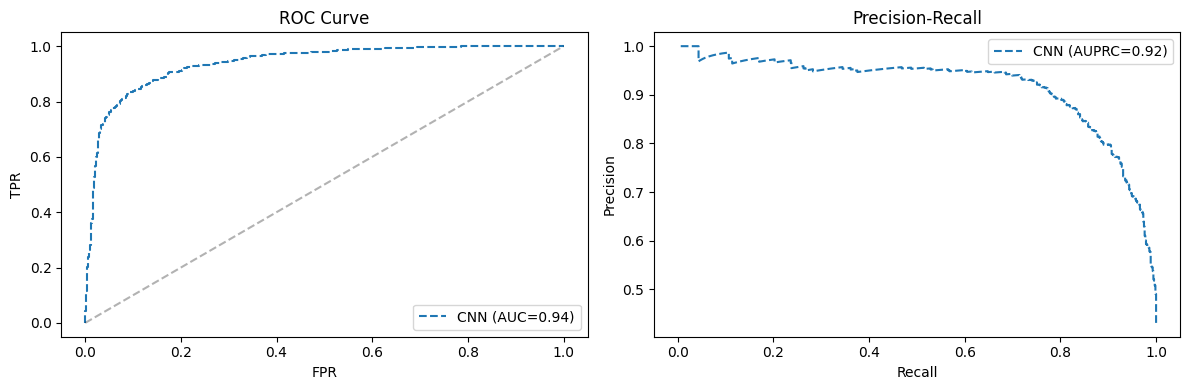

CNN → AUROC: 0.9388957040512022 AUPRC: 0.9177061090838755


In [23]:
## 6. Unified evaluation on FULL_H5 test split (same test for both models)

import numpy as np
import torch
import h5py
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from pathlib import Path

FULL_H5 = Path(DATASET_H5)
assert FULL_H5.exists(), f'Missing FULL_H5: {FULL_H5}'

# Prepare y_true once
with h5py.File(str(FULL_H5), 'r') as f:
    if 'label_strings' in f:
        def dec(x):
            s = x.decode('utf-8', 'ignore') if isinstance(x, (bytes, bytearray)) else str(x)
            return s.split('\x00', 1)[0].strip()
        ls = [dec(s) for s in f['label_strings'][:]]
        y_full_all = (~np.array([s == 'normal' for s in ls], dtype=bool)).astype(np.int64)
    else:
        y_full_all = (f['labels'][:].sum(axis=1) > 0).astype(np.int64)

y_true = y_full_all[test_idx_full]
print('FULL test size:', len(test_idx_full))

# Evaluate CNN on FULL test
if 'SmallCNN' not in globals():
    class SmallCNN(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.net = torch.nn.Sequential(
                torch.nn.Conv2d(1, 16, 3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
                torch.nn.Conv2d(16, 32, 3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
                torch.nn.Conv2d(32, 64, 3, padding=1), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
                torch.nn.Conv2d(64, 128, 3, padding=1), torch.nn.ReLU(), torch.nn.AdaptiveAvgPool2d((1,1))
            )
            self.cls = torch.nn.Sequential(torch.nn.Flatten(), torch.nn.Linear(128, 2))
        def forward(self, x):
            return self.cls(self.net(x))

cnn_scores = None
if Path(CNN_BEST).exists():
    ds_full = FullH5BinaryIndexDataset(FULL_H5, test_idx_full)
    dl_full = torch.utils.data.DataLoader(ds_full, batch_size=32, shuffle=False, num_workers=0)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    m = SmallCNN().to(device)
    m.load_state_dict(torch.load(CNN_BEST, map_location=device))
    m.eval()
    out = []
    with torch.no_grad():
        for xb, _ in dl_full:
            pb = torch.softmax(m(xb.to(device)), dim=1)[:,1].cpu().numpy()
            out.append(pb)
    cnn_scores = np.concatenate(out, axis=0)
    print('CNN scoring done.')
else:
    print('CNN checkpoint not found; skipping CNN eval.')

# Evaluate SSL on FULL test (if checkpoint is present)
ssl_scores = None
ssl_ckpt = Path(SSL_RESULTS.get('checkpoint', '')) if 'SSL_RESULTS' in globals() else Path(SSL_FT_CKPT)
if ssl_ckpt and ssl_ckpt.exists():
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path('/home/sbialek/ONC/selfsupervision_anomalies_onc/src')))
    from ssamba.utilities.training_utils import create_model
    from types import SimpleNamespace
    args = SimpleNamespace(
        task='ft_avgtok', num_mel_bins=512, target_length=512, fshape=16, tshape=16, fstride=16, tstride=16,
        model_size='base', exp_dir=str(ssl_ckpt.parent.parent), pretrained_path=str(ssl_ckpt),
        multiclass=False, n_class=2, patch_size=16, stride=16, embed_dim=768, depth=24, channels=1,
        num_classes=2, drop_rate=0.0, drop_path_rate=0.1, norm_epsilon=1e-5, rms_norm=True,
        residual_in_fp32=True, fused_add_norm=True, if_rope=False, if_rope_residual=False,
        bimamba_type='v2', if_cls_token=True, if_devide_out=True, use_double_cls_token=False,
        use_middle_cls_token=True, final_pool_type='mean'
    )
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = create_model(args).to(device)
    model.eval()
    ds_full = FullH5BinaryIndexDataset(FULL_H5, test_idx_full)
    dl_full = torch.utils.data.DataLoader(ds_full, batch_size=16, shuffle=False, num_workers=0)
    out = []
    with torch.no_grad():
        for xb, _ in dl_full:
            p = torch.sigmoid(model(xb.to(device), 'ft_avgtok')).flatten().cpu().numpy()
            out.append(p)
    ssl_scores = np.concatenate(out, axis=0)
    print('SSL scoring done.')
else:
    print('SSL checkpoint not found; skipping SSL eval.')

# Metrics and plots
plt.figure(figsize=(12, 4))

# ROC
plt.subplot(1,2,1)
if cnn_scores is not None:
    fpr_cnn, tpr_cnn, _ = roc_curve(y_true, cnn_scores)
    auc_cnn = auc(fpr_cnn, tpr_cnn)
    plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC={auc_cnn:.2f})', linestyle='--')
if ssl_scores is not None:
    fpr_ssl, tpr_ssl, _ = roc_curve(y_true, ssl_scores)
    auc_ssl = auc(fpr_ssl, tpr_ssl)
    plt.plot(fpr_ssl, tpr_ssl, label=f'SSL (AUC={auc_ssl:.2f})')
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend()

# PR
plt.subplot(1,2,2)
if cnn_scores is not None:
    prec_cnn, rec_cnn, _ = precision_recall_curve(y_true, cnn_scores)
    auprc_cnn = auc(rec_cnn, prec_cnn)
    plt.plot(rec_cnn, prec_cnn, label=f'CNN (AUPRC={auprc_cnn:.2f})', linestyle='--')
if ssl_scores is not None:
    prec_ssl, rec_ssl, _ = precision_recall_curve(y_true, ssl_scores)
    auprc_ssl = auc(rec_ssl, prec_ssl)
    plt.plot(rec_ssl, prec_ssl, label=f'SSL (AUPRC={auprc_ssl:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall'); plt.legend()

plt.tight_layout()
plt.show()

if cnn_scores is not None:
    print('CNN → AUROC:', roc_auc_score(y_true, cnn_scores), 'AUPRC:', average_precision_score(y_true, cnn_scores))
if ssl_scores is not None:
    print('SSL → AUROC:', roc_auc_score(y_true, ssl_scores), 'AUPRC:', average_precision_score(y_true, ssl_scores))



In [ ]:
## 6. Unified evaluation and plots (same SMALL test split)

import numpy as np
import torch
import h5py
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
from pathlib import Path

# Use SMALL_H5 from global config

# Prepare y_true from SMALL test split once
with h5py.File(str(SMALL_H5), 'r') as f:
    test_idx = f['split/test_idx'][:]
    if 'label_strings' in f:
        def dec(x):
            return x.decode('utf-8') if isinstance(x, (bytes, bytearray)) else str(x)
        ls = [dec(s) for s in f['label_strings'][:]]
        is_normal_full = np.array([s == 'normal' for s in ls], dtype=bool)
        y_full = (~is_normal_full).astype(np.int64)
    else:
        y_full = (f['labels'][:].sum(axis=1) > 0).astype(np.int64)
    y_true_small = y_full[test_idx]

# CNN results come from previous cell
cnn_scores = CNN_RESULTS['y_prob']
assert len(cnn_scores) == len(y_true_small), 'Size mismatch for CNN test scores.'

# SSL scores: run quick inference using checkpoint if present
ssl_scores = None
ssl_ckpt = Path(SSL_RESULTS.get('checkpoint', '')) if 'SSL_RESULTS' in globals() else Path('')
if ssl_ckpt.exists():
    # Build model similarly to training utils and score the SMALL test set directly
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path('/home/sbialek/ONC/selfsupervision_anomalies_onc/src')))
    from ssamba.utilities.training_utils import create_model
    from ssamba.utilities.checkpoint_utils import load_checkpoint
    from types import SimpleNamespace

    args = SimpleNamespace(
        task='ft_avgtok',
        num_mel_bins=512,
        target_length=512,
        fshape=16,
        tshape=16,
        fstride=16,
        tstride=16,
        model_size='base',
        exp_dir=str(ssl_ckpt.parent.parent),
        pretrained_path=str(ssl_ckpt),
        multiclass=False,
        n_class=2,
        patch_size=16,
        stride=16,
        embed_dim=768,
        depth=24,
        channels=1,
        num_classes=2,
        drop_rate=0.0,
        drop_path_rate=0.1,
        norm_epsilon=1e-5,
        rms_norm=True,
        residual_in_fp32=True,
        fused_add_norm=True,
        if_rope=False,
        if_rope_residual=False,
        bimamba_type='v2',
        if_cls_token=True,
        if_devide_out=True,
        use_double_cls_token=False,
        use_middle_cls_token=True,
        final_pool_type='mean'
    )
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = create_model(args).to(device)

    # Load finetuned weights (including head) from previous cell's checkpoint
    ckpt = load_checkpoint(str(ssl_ckpt), device)
    state_dict = ckpt.get('model_state_dict', ckpt)
    if any(k.startswith('module.') for k in state_dict.keys()):
        state_dict = { (k[7:] if k.startswith('module.') else k): v for k, v in state_dict.items() }
    model.load_state_dict(state_dict, strict=False)
    model.eval()

    # Iterate SMALL test set in memory-efficient way
    scores = []
    with h5py.File(str(SMALL_H5), 'r') as f:
        test_idx = f['split/test_idx'][:]
        for j in test_idx:
            x = f['spectrograms'][int(j)].astype(np.float32)  # (512,512,1)
            xmin, xmax = float(x.min()), float(x.max())
            if xmax > xmin:
                x = (x - xmin) / (xmax - xmin)
            x = np.transpose(x, (2,0,1))[None, ...]  # (1,1,512,512)
            with torch.no_grad():
                p = torch.sigmoid(model(torch.from_numpy(x).to(device), 'ft_avgtok')).flatten().item()
            scores.append(p)
    ssl_scores = np.array(scores, dtype=np.float32)

# Plot ROC and PR
plt.figure(figsize=(12, 4))

# ROC
plt.subplot(1,2,1)
fpr_cnn, tpr_cnn, _ = roc_curve(y_true_small, cnn_scores)
auc_cnn = auc(fpr_cnn, tpr_cnn)
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC={auc_cnn:.2f})', linestyle='--')
if ssl_scores is not None:
    fpr_ssl, tpr_ssl, _ = roc_curve(y_true_small, ssl_scores)
    auc_ssl = auc(fpr_ssl, tpr_ssl)
    plt.plot(fpr_ssl, tpr_ssl, label=f'SSL (AUC={auc_ssl:.2f})')
plt.plot([0,1],[0,1],'k--', alpha=0.3)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend()

# PR
plt.subplot(1,2,2)
prec_cnn, rec_cnn, _ = precision_recall_curve(y_true_small, cnn_scores)
auprc_cnn = auc(rec_cnn, prec_cnn)
plt.plot(rec_cnn, prec_cnn, label=f'CNN (AUPRC={auprc_cnn:.2f})', linestyle='--')
if ssl_scores is not None:
    prec_ssl, rec_ssl, _ = precision_recall_curve(y_true_small, ssl_scores)
    auprc_ssl = auc(rec_ssl, prec_ssl)
    plt.plot(rec_ssl, prec_ssl, label=f'SSL (AUPRC={auprc_ssl:.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall'); plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Paths are defined in the global config cell above
from pathlib import Path
print('DATASET_H5 =', DATASET_H5)
if not Path(DATASET_H5).exists():
    print('Warning: dataset path does not exist. Update DATASET_H5 in the config cell.')


## 3. Train the self‑supervised model

Pre‑train the SSAMBA model with a masked patch joint objective and then fine‑tune it for classification. Adjust `batch-size`, `epochs`, and dataset path as needed.

- Set `DATASET_H5` to point to your HDF5 dataset
- `EXP_DIR` is where checkpoints and logs will be written


In [ ]:
# Ensure repo src is importable for `ssamba.*`
import sys, pathlib
repo_root = pathlib.Path('/home/sbialek/ONC/selfsupervision_anomalies_onc').resolve()
src_path = str(repo_root / 'src')
# Dedup and prepend
sys.path = [p for p in sys.path if p != src_path]
sys.path.insert(0, src_path)
print('Using src path:', src_path)


Using src path: /home/sbialek/ONC/selfsupervision_anomalies_onc/src


### Customize the SSL tasks

We define `WorkshopAMBAModel` that inherits from the original and re‑implements `mpc` and `mpg` with a clearer, commented layout. These are the methods you would want to edit if you were interested in changing the self-supervised pretraining tasks.

Note: we will not be changing these during the workshop


In [ ]:
# Re-define WorkshopAMBAModel with clearer structure, rich comments, and forward()
import torch
from ssamba.models.both_models import AMBAModel

class WorkshopAMBAModel(AMBAModel):
    """
    Workshop-focused subclass that keeps the original behavior but makes
    the self-supervised objectives (mpc/mpg) and the task switch (forward)
    explicit and easy to read/tweak.

    Patch grid intuition (F x T = 512 x 512, patch_size = 16 x 16):

        F (freq)
        512 ┌────────────────────────────────────────────────────┐
            │ 32 rows of 16-bin patches (F) × 32 cols of 16-bin │
            │ patches (T) → 32×32 = 1024 patches total          │
            │  [r0c0] [r0c1] ... [r0c31]                        │
            │  [r1c0] [r1c1] ... [r1c31]                        │
            │   ...                                             │
            │  [r31c0] ...                  [r31c31]            │
            └────────────────────────────────────────────────────┘ 0
               0                    512 time → 32 cols of 16

    Flattened index idea: index(r, c) ≈ r * 32 + c.

    Masking:
    - cluster=True  → sample a c×c block (spatially coherent masking)
    - cluster=False → sample random distinct indices across the entire grid

    Why masking?
    - mpc teaches the model to identify which patch content is correct
      among negatives (discriminative InfoNCE). This encourages
      context-aware token representations.
    - mpg teaches the model to reconstruct the exact masked patch content
      (generative MSE). This encourages detailed local representations.
    """

    def mpc(self, x, mask_patch, cluster, show_mask: bool = False):
        """
        Masked Patch Classification (discriminative objective)

        High-level:
        1) Unfold spectrogram into flattened 16×16 patches → targets for masking.
        2) Choose mask indices (clustered vs random) to hide some patches.
        3) Replace the corresponding token embeddings with a learnable mask vector.
        4) Run the backbone (Vision Mamba) to produce contextualized token outputs.
        5) For each masked token, project to patch space (256 dims) and compute
           InfoNCE vs its true target patch and other negatives in the batch.

        Why InfoNCE? It forces the model to produce embeddings that are most
        similar to their correct reconstruction and dissimilar to others,
        improving contextual understanding.
        """
        # 1) Build ground-truth targets: unfold (B, 1, 512, 512) → (B, num_patches, 256)
        unfolded_targets = self.unfold(x).transpose(1, 2)
        B = x.shape[0]

        # 2) Patch-embed the input (tokens shape: B × num_patches × embed_dim)
        tokens = self.v.patch_embed(x)

        # Prepare containers for masking setup
        encode_samples = torch.empty((B, mask_patch, 256), device=tokens.device, requires_grad=False).float()
        mask_index     = torch.empty((B, mask_patch), device=tokens.device, requires_grad=False).long()
        # mask_dense acts as a per-token switch: 1 = keep original token, 0 = replace by mask token
        mask_dense     = torch.ones_like(tokens)

        # 2b) Decide which tokens to mask for each sample
        for i in range(B):
            if cluster:
                mask_index[i] = self.gen_maskid_patch(self.num_patches, mask_patch)
            else:
                mask_index[i] = self.gen_maskid_frame(self.num_patches, mask_patch)
            # Save the true (unfolded) targets for masked positions
            encode_samples[i] = unfolded_targets[i, mask_index[i], :].clone().detach()
            # Flip the switch to 0 where we will place mask tokens
            mask_dense[i, mask_index[i], :] = 0

        # 3) Replace chosen tokens by a learnable mask embedding
        mask_tokens = self.mask_embed.expand(B, tokens.shape[1], -1)
        tokens = tokens * mask_dense + (1 - mask_dense) * mask_tokens

        # 4) Add a class token and positional encoding; run the backbone for context
        cls_tokens = self.v.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_tokens, tokens), dim=1)
        tokens = tokens + self.v.pos_embed
        tokens = self.v.pos_drop(tokens)

        residual = None
        hidden = tokens
        if not self.v.if_bidirectional:
            for layer in self.v.layers:
                hidden, residual = layer(hidden, residual)
        else:
            for i in range(len(self.v.layers) // 2):
                hf, rf = self.v.layers[i * 2](hidden, residual)
                hb, rb = self.v.layers[i * 2 + 1](hidden.flip([1]), None if residual is None else residual.flip([1]))
                hidden = hf + hb.flip([1])
                residual = rf + rb.flip([1])

        hidden = self.v.norm_f(hidden)

        # 5) Predict the masked tokens and compute InfoNCE
        pred = torch.empty((B, mask_patch, 256), device=hidden.device).float()
        for i in range(B):
            # +cls offset because we prepended the class token at index 0
            pred[i] = self.cpredlayer(hidden[i, mask_index[i] + self.cls_token_num, :])

        nce   = torch.tensor(0.0, device=hidden.device)
        corr  = torch.tensor(0.0, device=hidden.device)
        for i in range(B):
            # Similarity of predictions to their true targets (each sample provides negatives for the others)
            sim = torch.mm(encode_samples[i], pred[i].T)
            # Count how often the top-1 predicted index matches the correct index
            corr += torch.sum(torch.eq(torch.argmax(self.softmax(sim), dim=0), torch.arange(0, mask_patch, device=hidden.device)))
            # NCE loss (negative log probability of the correct target)
            nce  += torch.sum(torch.diag(self.lsoftmax(sim)))

        acc = 1.0 * corr / (B * mask_patch)
        nce = nce / (-1.0 * B * mask_patch)

        if not show_mask:
            return acc, nce
        else:
            # Optional visualization tensors: predicted vs masked areas folded back to 2D
            fold = torch.nn.Fold(output_size=([self.input_fdim, self.input_tdim]), kernel_size=(self.fshape, self.tshape), stride=(self.fstride, self.tstride))
            pred_map   = unfolded_targets.clone()
            masked_map = unfolded_targets.clone()
            for i in range(B):
                sim = torch.mm(encode_samples[i], pred[i].T)
                ok  = torch.eq(torch.argmax(self.softmax(sim), dim=0), torch.arange(0, mask_patch, device=hidden.device)).float() * 99
                pred_map[i, mask_index[i], :]   = ok.unsqueeze(1).expand(mask_patch, 256)
                masked_map[i, mask_index[i], :] = 99.0
            return fold(pred_map.transpose(1, 2)), fold(masked_map.transpose(1, 2))

    def mpg(self, x, mask_patch, cluster):
        """
        Masked Patch Generation (generative objective)

        High-level:
        1) Unfold spectrogram into flattened patch targets → the "ground truth" 16×16 values.
        2) Choose mask indices and replace the corresponding token embeddings with a learnable mask embedding.
        3) Run the backbone to propagate context from visible tokens to masked ones.
        4) Predict the masked patch pixel values and minimize MSE(pred, target).

        Why MSE? It forces the model to carry detailed local information so it can
        reconstruct the exact content of the masked region.
        """
        B = x.shape[0]

        # 1) Tokenize and build unfolded targets (what we want to reconstruct)
        tokens = self.v.patch_embed(x)                    # [B, num_patches, embed_dim]
        unfolded_targets = self.unfold(x).transpose(1, 2) # [B, num_patches, 256]

        # 2) Decide which tokens to mask
        mask_index = torch.empty((B, mask_patch), device=tokens.device, requires_grad=False).long()
        mask_dense = torch.ones_like(tokens)
        for i in range(B):
            mask_index[i] = self.gen_maskid_patch(self.num_patches, mask_patch) if cluster else self.gen_maskid_frame(self.num_patches, mask_patch)
            mask_dense[i, mask_index[i], :] = 0

        # Replace masked token embeddings with a learnable mask vector
        mask_tokens = self.mask_embed.expand(B, tokens.shape[1], -1)
        tokens = tokens * mask_dense + (1 - mask_dense) * mask_tokens

        # 3) Add cls + positional embeddings, then run the backbone for context
        cls_tokens = self.v.cls_token.expand(B, -1, -1)
        tokens = torch.cat((cls_tokens, tokens), dim=1)
        tokens = tokens + self.v.pos_embed
        tokens = self.v.pos_drop(tokens)

        residual = None
        hidden = tokens
        if not self.v.if_bidirectional:
            for layer in self.v.layers:
                hidden, residual = layer(hidden, residual)
        else:
            for i in range(len(self.v.layers) // 2):
                hf, rf = self.v.layers[i * 2](hidden, residual)
                hb, rb = self.v.layers[i * 2 + 1](hidden.flip([1]), None if residual is None else residual.flip([1]))
                hidden = hf + hb.flip([1])
                residual = rf + rb.flip([1])

        hidden = self.v.norm_f(hidden)

        # 4) Predict masked patch pixel values (256 = 16×16) and compute MSE
        pred   = torch.empty((B, mask_patch, self.fshape * self.tshape), device=hidden.device).float()
        target = torch.empty((B, mask_patch, self.fshape * self.tshape), device=hidden.device).float()
        for i in range(B):
            pred[i]   = self.gpredlayer(hidden[i, mask_index[i] + self.cls_token_num, :])
            target[i] = unfolded_targets[i, mask_index[i], :]

        mse = torch.mean((pred - target) ** 2)
        return mse

    def forward(self, x, task, cluster: bool = True, mask_patch: int = 400):
        """
        Task switch:
          - 'pretrain_mpc'   → discriminative masked patch classification
          - 'pretrain_mpg'   → generative masked patch reconstruction
          - 'pretrain_joint' → both; return (acc, mse) in validation, (acc, loss) in train
          - 'visualize_mask' → return visualization tensors for MPC
          - 'ft_*'           → finetune heads (handled in base class), requires x in (B, 1, F, T) with F=T=512

        We keep input orientation rules from the base model:
          - Finetune tasks transpose to (B, 1, F, T); pretrain tasks keep (B, 1, T, F) → but our code expects 512×512.
        """
        # Harmonize input ranks as in the base class
        if x.dim() == 3:     # (B, T, F)
            x = x.unsqueeze(1)
        elif x.dim() == 4:   # (B, H, W, C)
            if x.shape[-1] == 1:
                x = x.permute(0, 3, 1, 2)
        elif x.dim() == 5:   # (B, 1, T, F, 1)
            x = x.squeeze(-1)

        # Finetune tasks expect (B, 1, F, T); pretrain keeps original
        if task in ['ft_avgtok', 'ft_avgtok_1sec', 'ft_cls']:
            x = x.transpose(2, 3)

        B, C, T, F = x.shape
        if T != 512 or F != 512:
            raise ValueError(f'Input shape {x.shape} does not match expected shape (B, 1, 512, 512)')
        if C != 1:
            raise ValueError(f'Expected 1 channel but got {C} channels')

        if task == 'pretrain_mpc':
            return self.mpc(x, mask_patch=mask_patch, cluster=cluster)
        elif task == 'pretrain_mpg':
            return self.mpg(x, mask_patch=mask_patch, cluster=cluster)
        elif task == 'pretrain_joint':
            acc, _ = self.mpc(x, mask_patch=mask_patch, cluster=cluster)
            mse    = self.mpg(x, mask_patch=mask_patch, cluster=cluster)
            return acc, mse
        elif task == 'visualize_mask':
            return self.mpc(x, mask_patch=mask_patch, cluster=cluster, show_mask=True)
        elif task in ['ft_avgtok', 'ft_avgtok_1sec', 'ft_cls']:
            # Delegate to base finetune heads
            return super().forward(x, task, cluster=cluster, mask_patch=mask_patch)
        else:
            raise ValueError(f"Task '{task}' not recognized.")


In [ ]:
%%bash
DATASET_H5="/home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5"
EXP_DIR="/home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments"
mkdir -p "$EXP_DIR"

python3 /home/sbialek/ONC/selfsupervision_anomalies_onc/src/run_amba_spectrogram.py \
  --data-train "$DATASET_H5" \
  --task pretrain_joint \
  --batch-size 8 \
  --n-epochs 3 \
  --train_ratio 0.8 \
  --val_ratio 0.1 \
  --target_length 512 \
  --num_mel_bins 512 \
  --fshape 16 --tshape 16 --fstride 16 --tstride 16 \
  --num_classes 0 \
  --exp-dir "$EXP_DIR" \
  --dataset_mean 0.0 --dataset_std 1.0

/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


VisionMamba imported successfully
RMSNorm imported successfully
I am process 79514, running on ONC002458: starting (Fri Oct 24 17:03:16 2025)
[DEBUG] Parsed args: exp_dir=/home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments, data_train=/home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5, task=pretrain_joint, resume=False, num_classes=0, multiclass=False
[DEBUG] Ensured exp dirs exist: /home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments
[DEBUG] CWD: /home/sbialek/ONC/selfsupervision_anomalies_onc/notebooks
[DEBUG] List exp_dir: ['args.pkl', 'models', 'predictions']

Dataset split ratios:
Train: 80.0%
Val: 10.0%
Test: 10.0%
Using random seed: 42
Creating train/val/test splits from ONC dataset
Excluding labels: None

=== DATASET CONFIGURATION ===
Data path: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Split ratios - Train: 

Traceback (most recent call last):
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/src/run_amba_spectrogram.py", line 445, in <module>
    trainmask(None, train_loader, val_loader, args)
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/src/ssamba/traintest_mask.py", line 75, in trainmask
    global_step, train_metrics = training_loop(
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/src/ssamba/utilities/training_utils.py", line 485, in training_loop
    loss.backward()
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/torch/_tensor.py", line 648, in backward
    torch.autograd.backward(
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/torch/autograd/__init__.py", line 353, in backward
    _engine_run_backward(
  File "/home/sbialek/ONC/selfsupervision_anomalies_onc/.venv/lib/python3.10/site-packages/torch/autograd/graph.py", line 824, in _engine_run_backward
    return Variable._exe

In [ ]:
PRETRAINED_PATH="/home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments/models/pretrain-best.pth"  # Update with your pretrained SSL checkpoint file

python3 /home/sbialek/ONC/selfsupervision_anomalies_onc/src/run_amba_spectrogram.py \
    --data-train "$DATASET_H5" \
    --task ft_avgtok \
    --pretrained_path "$PRETRAINED_PATH" \
    --batch-size 8 \
    --n-epochs 3 \
    --train_ratio 0.8 \
    --val_ratio 0.1 \
    --target_length 512 \
    --num_mel_bins 512 \
    --fshape 16 \
    --tshape 16 \
    --fstride 16 \
    --tstride 16 \
    --exp-dir "$EXP_DIR"


## 4. Supervised baseline: a small CNN

A simple CNN for comparison. Replace the synthetic dataset with your actual spectrogram tensors or HDF5 loader.


## 5. Evaluate your own audio file (local path)

Set `AUDIO_PATH` to a local `.wav` (or supported) file and compute anomaly probability using a fine‑tuned SSAMBA checkpoint. Update `CHECKPOINT_PATH` to your finetuned model checkpoint (`*_best_checkpoint.pth` or similar).


In [ ]:
import torch
import numpy as np
import librosa
from pathlib import Path

# Using AUDIO_PATH and CHECKPOINT_PATH from the global config cell

# Preprocess audio to mel-spectrogram-like input matching model expectations
# NOTE: Align with training defaults: num_mel_bins=512, target_length=512
n_mels = 512
n_fft = 1024
hop_length = 512

y, sr = librosa.load(str(AUDIO_PATH), sr=None)
S = librosa.feature.melspectrogram(y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
S_db = librosa.power_to_db(S, ref=np.max)

# Normalize 0..1
S_min, S_max = S_db.min(), S_db.max()
S_norm = (S_db - S_min) / max(S_max - S_min, 1e-8)

# Pad/crop time dimension to 512 frames
T = S_norm.shape[1]
if T < 512:
    pad = 512 - T
    S_padded = np.pad(S_norm, ((0, 0), (0, pad)), mode='constant')
else:
    S_padded = S_norm[:, :512]

# Add batch and channel dims, and permute to (B, 1, F, T) for finetune tasks
x = torch.tensor(S_padded, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1, F, T)
x = x  # already (B,1,F,T); model will transpose internally for ft_* tasks

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Build model using training utilities to ensure correct config
from ssamba.utilities.training_utils import create_model
from types import SimpleNamespace

args = SimpleNamespace(
    task='ft_avgtok',
    num_mel_bins=512,
    target_length=512,
    fshape=16,
    tshape=16,
    fstride=16,
    tstride=16,
    model_size='base',
    exp_dir=str(CHECKPOINT_PATH.parent.parent),  # exp_dir/ models /
    pretrained_path=str(CHECKPOINT_PATH),
    multiclass=False,
    n_class=2,
    patch_size=16,
    stride=16,
    embed_dim=768,
    depth=24,
    channels=1,
    num_classes=2,
    drop_rate=0.0,
    drop_path_rate=0.1,
    norm_epsilon=1e-5,
    rms_norm=True,
    residual_in_fp32=True,
    fused_add_norm=True,
    if_rope=False,
    if_rope_residual=False,
    bimamba_type='v2',
    if_cls_token=True,
    if_devide_out=True,
    use_double_cls_token=False,
    use_middle_cls_token=True,
    final_pool_type='mean'
)

model = create_model(args).to(device)
model.eval()

with torch.no_grad():
    logits = model(x.to(device), args.task)
    prob = torch.sigmoid(logits).squeeze().item()
print(f"Anomaly probability: {prob:.3f}")


## 6. Save/Archive experiment outputs

Create a timestamped tar.gz of the experiment directory for backup or sharing.


In [ ]:
EXP_DIR="/home/sbialek/ONC/selfsupervision_anomalies_onc/ssamba_experiments"
TS=$(date +%Y%m%d_%H%M%S)
OUT="ssamba_experiments_${TS}.tar.gz"

if [ -d "$EXP_DIR" ]; then
  tar -czf "$OUT" -C "$(dirname "$EXP_DIR")" "$(basename "$EXP_DIR")"
  echo "Archived to $OUT"
else
  echo "Experiment directory not found: $EXP_DIR"
fi


## 7. ROC and Precision‑Recall curves (replace with actual results)

Quick plotting utilities; replace placeholders with your model outputs.


In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt

# Replace these with actual results
y_true = np.random.randint(0, 2, 100)
ssl_scores = np.random.rand(100)
cnn_scores = np.random.rand(100)

fpr_ssl, tpr_ssl, _ = roc_curve(y_true, ssl_scores)
fpr_cnn, tpr_cnn, _ = roc_curve(y_true, cnn_scores)
prec_ssl, rec_ssl, _ = precision_recall_curve(y_true, ssl_scores)
prec_cnn, rec_cnn, _ = precision_recall_curve(y_true, cnn_scores)

roc_auc_ssl = auc(fpr_ssl, tpr_ssl)
roc_auc_cnn = auc(fpr_cnn, tpr_cnn)
pr_auc_ssl = auc(rec_ssl, prec_ssl)
pr_auc_cnn = auc(rec_cnn, prec_cnn)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(fpr_ssl, tpr_ssl, label=f'SSL (AUC={roc_auc_ssl:.2f})')
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC={roc_auc_cnn:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(rec_ssl, prec_ssl, label=f'SSL (AUPRC={pr_auc_ssl:.2f})')
plt.plot(rec_cnn, prec_cnn, label=f'CNN (AUPRC={pr_auc_cnn:.2f})', linestyle='--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

plt.tight_layout()
plt.show()


## 8. Next steps and resources

- Try other SSAMBA tasks (`pretrain_mpc`, `pretrain_mpg`) and fine‑tuning strategies (`ft_cls`).
- Tune hyperparameters: batch size, learning rate, and epochs.
- Use the interactive labeling tool in `tools/labeling/run.py` to expand labeled data.
- For larger experiments, prefer a machine with full CUDA toolkit and more VRAM.

Further reading
- See repository README for tasks and model usage.
- Dataset prep details in `src/ssamba/dataset.py`.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# Replace this with actual HDF5 loading code

def load_dataset():
    num_samples = 100
    num_classes = 2
    X = np.random.randn(num_samples, 1, 128, 128).astype(np.float32)
    y = np.random.randint(0, num_classes, size=num_samples)
    return X, y

class SmallCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(64, num_classes))
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def prepare_dataloaders(batch_size=16, val_ratio=0.1, test_ratio=0.1):
    X, y = load_dataset()
    dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
    total = len(dataset)
    n_val = int(val_ratio * total)
    n_test = int(test_ratio * total)
    n_train = total - n_val - n_test
    train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])
    return DataLoader(train_set, batch_size=batch_size, shuffle=True), DataLoader(val_set, batch_size=batch_size), DataLoader(test_set, batch_size=batch_size)

def train_model(model, train_loader, val_loader, epochs=3, lr=1e-3):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(Xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
        train_loss /= len(train_loader.dataset)
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                preds = model(Xb)
                loss = loss_fn(preds, yb)
                val_loss += loss.item() * Xb.size(0)
                correct += (preds.argmax(dim=1) == yb).sum().item()
                total += yb.size(0)
        val_loss /= len(val_loader.dataset)
        print(f'Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={correct/total:.4f}')
    return model

def evaluate_model(model, test_loader):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    y_true, y_score = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb = Xb.to(device)
            logits = model(Xb)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_score.extend(probs)
            y_true.extend(yb.numpy())
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    auc_roc = roc_auc_score(y_true, y_score)
    auc_pr = average_precision_score(y_true, y_score)
    cm = confusion_matrix(y_true, (y_score > 0.5).astype(int))
    return auc_roc, auc_pr, cm

train_loader, val_loader, test_loader = prepare_dataloaders()
cnn_model = SmallCNN()
cnn_model = train_model(cnn_model, train_loader, val_loader, epochs=3)
roc_auc, pr_auc, cm = evaluate_model(cnn_model, test_loader)
print(f'Supervised CNN → ROC AUC: {roc_auc:.3f}, AUPRC: {pr_auc:.3f}')
print('Confusion Matrix:\n', cm)
